# Rectified Flow from scratch

В прошлый раз мы кратко обсудили идею `rectified flow` как моделирование непрерывного поля скоростей для перехода из распределения шума в распределение данных

Данный ноутбук показывает

1. Как обучать `rectified flow`
2. Насколько `flow matching` и `diffusion` модели похожи между собой (с некоторыми оговорками, это одно и то же)

In [ ]:
%pip install -qq -U diffusers datasets transformers accelerate ftfy pyarrow==9.0.0

     |████████████████████████████████| 255 kB 16.0 MB/s 
     |████████████████████████████████| 163 kB 53.9 MB/s 


### Данные

пункт перенесен из `ddpm-basics`

device=device(type='cuda')


Repo card metadata block was not found. Setting CardData to empty.


X shape: torch.Size([8, 3, 32, 32])


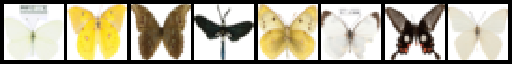

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from PIL import Image

import torchvision
from datasets import load_dataset
from torchvision import transforms
from diffusers import UNet2DModel


def show_images(x):
    """Given a batch of images x, make a grid and convert to PIL"""
    x = x * 0.5 + 0.5  # Map from (-1, 1) back to (0, 1)
    x = x.clamp(0, 1)
    grid = torchvision.utils.make_grid(x)
    grid_im = grid.detach().cpu().permute(1, 2, 0) * 255
    grid_im = Image.fromarray(np.array(grid_im).astype(np.uint8))
    return grid_im


def make_grid(images, size=64):
    """Given a list of PIL images, stack them together into a line for easy viewing"""
    output_im = Image.new("RGB", (size * len(images), size))
    for i, im in enumerate(images):
        output_im.paste(im.resize((size, size)), (i * size, 0))
    return output_im


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device=}")

dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

image_size = 32
batch_size = 32

preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),  # -> [-1, 1]
    ]
)


def transform(examples):
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

xb = next(iter(train_dataloader))["images"].to(device)[:8]
print("X shape:", xb.shape)
show_images(xb).resize((8 * 64, 64), resample=Image.NEAREST)

### Архитектура

Пункт также перенесен из `ddpm-basics`

**Note** Заметим, что в diffusion мы делаем дискретные шаги, а в rectified flow - непрерывные. Хелпер функции ниже помогут решить эту проблему

In [ ]:
model = UNet2DModel(
    sample_size=image_size,
    in_channels=3,
    out_channels=3,  # predict velocity field, same shape as image
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)

In [ ]:
# Diffusers UNet expects a timestep-like input.
# For continuous time t in [0,1], удобно просто масштабировать его в [0,999].
def t_to_model_time(t):
    return t * 999.0


def sample_flow_batch(x0):
    """
    x0: clean images from dataset, shape [B, C, H, W]
    Returns:
        xt: interpolated point on line from noise to data
        t: continuous time in [0,1], shape [B]
        target_v: target velocity field, shape [B, C, H, W]
        x1: starting noise
    """
    x1 = torch.randn_like(x0)  # source distribution
    b = x0.shape[0]

    # Sample continuous time t
    t = torch.rand(b, device=x0.device)

    # reshape for broadcasting: [B,1,1,1]
    t_view = t.view(b, 1, 1, 1)

    # straight-line interpolation from noise x1 to data x0
    xt = (1.0 - t_view) * x1 + t_view * x0

    # velocity along straight line
    target_v = x0 - x1

    return xt, t, target_v, x1

### Обучение

В отличии от ddpm, мы не используем здесь scheduler, а пишем формулы напрямую. Согласитесь, формулы, которые использует rectified flow сильно проще чем у ddpm (`sample_flow_batch` функция)

In [ ]:
from tqdm.notebook import tqdm

losses = []
num_epochs = 30

model.train()

for epoch in tqdm(range(num_epochs), leave=False):
    for step, batch in enumerate(train_dataloader):
        x0 = batch["images"].to(device)

        xt, t, target_v, _ = sample_flow_batch(x0)
        model_t = t_to_model_time(t)

        pred_v = model(xt, model_t, return_dict=False)[0]

        loss = F.mse_loss(pred_v, target_v)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    if (epoch + 1) % 5 == 0:
        loss_last_epoch = sum(losses[-len(train_dataloader):]) / len(train_dataloader)
        print(f"Epoch {epoch+1}: loss = {loss_last_epoch:.6f}")

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 5: loss = 0.259953
Epoch 10: loss = 0.205336
Epoch 15: loss = 0.197007
Epoch 20: loss = 0.184947
Epoch 25: loss = 0.178411
Epoch 30: loss = 0.163979


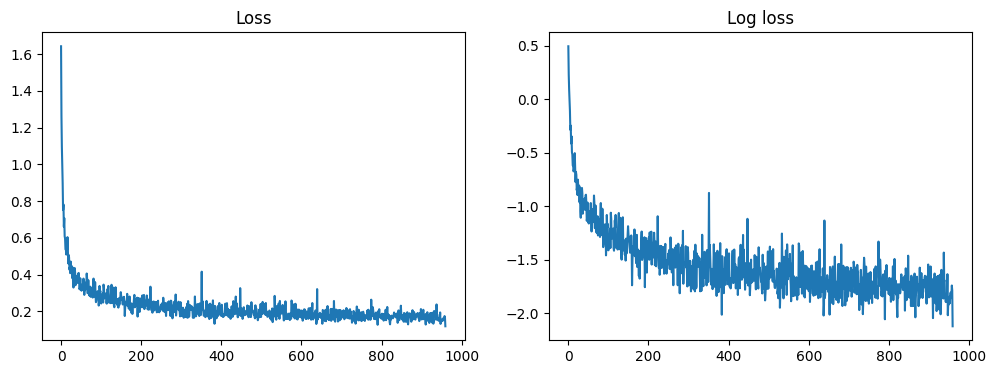

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[0].set_title("Loss")
axs[1].plot(np.log(np.array(losses) + 1e-8))
axs[1].set_title("Log loss")
plt.show()

### Семплирование

Для того, чтобы семплировать изображение, нам надо решить ODE.

Численных методов решения довольно много, но самый простой (и популярный) – метод Эйлера

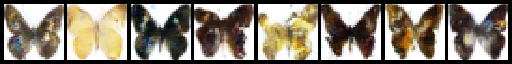

In [ ]:
@torch.no_grad()
def sample_rectified_flow(model, n_samples=8, num_steps=100, image_size=32, device="cuda"):
    model.eval()

    # Start from Gaussian noise: this is x(t=0)
    x = torch.randn(n_samples, 3, image_size, image_size, device=device)

    dt = 1.0 / num_steps

    for i in range(num_steps):
        t = torch.full((n_samples,), i / num_steps, device=device)
        model_t = t_to_model_time(t)

        v = model(x, model_t, return_dict=False)[0]
        x = x + dt * v

    return x


samples = sample_rectified_flow(
    model,
    n_samples=8,
    num_steps=100,
    image_size=image_size,
    device=device,
)

show_images(samples).resize((8 * 64, 64), resample=Image.NEAREST)

P.s. Реализации других ODE солверов: [Runge-Kutta 4 порядка](https://ru.wikipedia.org/wiki/%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%A0%D1%83%D0%BD%D0%B3%D0%B5_%E2%80%94_%D0%9A%D1%83%D1%82%D1%82%D1%8B) и [Heun](https://en.wikipedia.org/wiki/Heun%27s_method)

In [ ]:
@torch.no_grad()
def velocity(model, x, t):
    """
    x: [B, C, H, W]
    t: [B] in [0, 1]
    returns v(x,t): [B, C, H, W]
    """
    model_t = t_to_model_time(t)
    return model(x, model_t, return_dict=False)[0]


@torch.no_grad()
def sample_rectified_flow_rk4(
    model,
    n_samples=8,
    image_size=32,
    num_steps=100,
    device="cuda",
):
    model.eval()
    x = torch.randn(n_samples, 3, image_size, image_size, device=device)

    dt = 1.0 / num_steps

    for i in range(num_steps):
        t = torch.full((n_samples,), i / num_steps, device=device)

        k1 = velocity(model, x, t)
        k2 = velocity(model, x + 0.5 * dt * k1, t + 0.5 * dt)
        k3 = velocity(model, x + 0.5 * dt * k2, t + 0.5 * dt)
        k4 = velocity(model, x + dt * k3, t + dt)

        x = x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    return x

@torch.no_grad()
def sample_rectified_flow_heun(
    model,
    n_samples=8,
    image_size=32,
    num_steps=100,
    device="cuda",
):
    model.eval()
    x = torch.randn(n_samples, 3, image_size, image_size, device=device)

    dt = 1.0 / num_steps

    for i in range(num_steps):
        t = torch.full((n_samples,), i / num_steps, device=device)

        k1 = velocity(model, x, t)
        x_euler = x + dt * k1
        k2 = velocity(model, x_euler, t + dt)

        x = x + 0.5 * dt * (k1 + k2)

    return x